In [ ]:
# ----- Reproducibility: all random seeds documented here -----
SEED = 42                    # seed for RF and GBM
REPEATED_CV_SEEDS = range(20) # repeated-CV sweep (0..19) to quantify fold-split variance
from project_config import ACOUSTIC, CLINICAL, CLINICAL_ACOUSTIC
import numpy as np
np.random.seed(SEED)         # covers any incidental numpy randomness


In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, PoissonRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


warnings.filterwarnings("ignore", category=ConvergenceWarning)

models = {
    "Dummy":   DummyRegressor(strategy="mean"),
    "Linear":  make_pipeline(StandardScaler(), LinearRegression()),
    "Poisson": make_pipeline(StandardScaler(), PoissonRegressor(alpha=1.0, max_iter=5000)),
    "RF":      RandomForestRegressor(random_state=SEED),
    "GBM":     GradientBoostingRegressor(random_state=SEED),
}

print(f"{'feature set':18s}{'model':9s}{'R2':>16}{'MAE':>14}")
for sname, cols in feature_sets.items():
    for mname, m in models.items():
        r = repeated_cv(m, model_df[cols], y)            # 20x10-fold, mean±SD
        r = repeated_cv(m, model_df[cols], y)            # 20x10-fold, mean±SD
        r2_str = f"{r['R2'][0]:.3f}±{r['R2'][1]:.3f}"
        mae_str = f"{r['MAE'][0]:.3f}±{r['MAE'][1]:.3f}"
        print(f"{sname:18s}{mname:9s}{r2_str:>16}{mae_str:>14}")


feature set       model                  R2           MAE
Demographics      Dummy        -0.044±0.022   7.980±0.086
Demographics      Linear        0.356±0.024   5.281±0.112
Demographics      Poisson       0.283±0.034   5.808±0.148
Demographics      RF            0.188±0.061   5.964±0.254
Demographics      GBM           0.045±0.078   6.294±0.290
Psych             Dummy        -0.044±0.022   7.980±0.086
Psych             Linear        0.795±0.019   3.013±0.138
Psych             Poisson       0.303±0.153   4.182±0.251
Psych             RF            0.805±0.020   2.561±0.131
Psych             GBM           0.799±0.034   2.706±0.193
Clinical          Dummy        -0.044±0.022   7.980±0.086
Clinical          Linear        0.776±0.019   3.129±0.129
Clinical          Poisson       0.125±0.171   4.606±0.304
Clinical          RF            0.784±0.020   2.663±0.124
Clinical          GBM           0.765±0.034   2.766±0.166
Acoustic          Dummy        -0.044±0.022   7.980±0.086
Acoustic      

In [43]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

warnings.filterwarnings("ignore", category=ConvergenceWarning)

models = {
    "Dummy": DummyRegressor(strategy="mean"),
    "Ridge": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 4, 25))),
    "RF":    RandomForestRegressor(random_state=SEED),
    "GBM":   GradientBoostingRegressor(random_state=SEED),
}

metrics = ["R2", "MAE", "r"]
print(f"{'feature set':18s}{'model':7s}" + "".join(f"{m:>16}" for m in metrics))
for sname, cols in feature_sets.items():
    for mname, m in models.items():
        res = repeated_cv(m, model_df[cols], y)
        cells = "".join(f"{f'{res[k][0]:.3f}±{res[k][1]:.3f}':>16}" for k in metrics)
        print(f"{sname:18s}{mname:7s}{cells}")



feature set       model                R2             MAE               r
Demographics      Dummy      -0.044±0.022     7.980±0.086    -0.419±0.104
Demographics      Ridge       0.358±0.024     5.335±0.113     0.599±0.019
Demographics      RF          0.188±0.061     5.964±0.254     0.495±0.039
Demographics      GBM         0.045±0.078     6.294±0.290     0.452±0.047
Psych             Dummy      -0.044±0.022     7.980±0.086    -0.419±0.104
Psych             Ridge       0.801±0.014     3.011±0.113     0.895±0.008
Psych             RF          0.805±0.020     2.561±0.131     0.899±0.011
Psych             GBM         0.799±0.034     2.706±0.193     0.897±0.018
Clinical          Dummy      -0.044±0.022     7.980±0.086    -0.419±0.104
Clinical          Ridge       0.789±0.014     3.097±0.093     0.889±0.008
Clinical          RF          0.784±0.020     2.663±0.124     0.887±0.011
Clinical          GBM         0.765±0.034     2.766±0.166     0.878±0.018
Acoustic          Dummy      -0.044±0.

In [13]:
# Clinical-only baseline models (linear regression, Poisson regression)
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, PoissonRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.stats import pearsonr


DATA_DIR = Path.cwd()
if not (DATA_DIR / "model_df.csv").exists():
    DATA_DIR = DATA_DIR.parent

model_df = pd.read_csv(DATA_DIR / "model_df.csv")



# Clinical-only: select the clinical predictors explicitly (exclude all acoustic features).
clinical_predictors = ["age", "gender", "education_years", "ctq_sf", "LES", "SSRS", "gad7", "PSQI"]
X_clinical = model_df[clinical_predictors]
y = model_df["phq9"]

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)   # matches main pipeline (was n_splits=5)

lin = LinearRegression()
poisson = PoissonRegressor(alpha=0.0, max_iter=1000)

lin_pred     = cross_val_predict(lin, X_clinical, y, cv=kf, n_jobs=1)
poisson_pred = cross_val_predict(poisson, X_clinical, y, cv=kf, n_jobs=1)

def report(name, pred):
    print(f"{name:18s} MAE: {mean_absolute_error(y, pred):.3f}  "
          f"RMSE: {np.sqrt(mean_squared_error(y, pred)):.3f}  "
          f"R2: {r2_score(y, pred):.3f}  "
          f"r: {pearsonr(y, pred)[0]:.3f}")

report("Linear Regression", lin_pred)
report("Poisson Regression", poisson_pred)

Linear Regression  MAE: 3.144  RMSE: 3.994  R2: 0.774  r: 0.882
Poisson Regression MAE: 4.584  RMSE: 8.409  R2: -0.002  r: 0.662


In [14]:
# Acoustic-only baseline models (Random Forest, Gradient Boosting)
import sys
from pathlib import Path
_here = Path.cwd()
sys.path.insert(0, str(_here if (_here / "project_config.py").exists() else _here / "scripts"))
from project_config import *

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr

DATA_DIR = Path.cwd()
if not (DATA_DIR / "model_df.csv").exists():
    DATA_DIR = DATA_DIR.parent
model_df = pd.read_csv(DATA_DIR / "model_df.csv")

X_acoustic = model_df[ACOUSTIC]
y = model_df["phq9"]

kf = KFold(n_splits=10, shuffle=True, random_state=42) 

rf = RandomForestRegressor(random_state=SEED)
gb = GradientBoostingRegressor(random_state=SEED)

# Pool out-of-fold predictions, then compute one R²/MAE over all 52 subjects.
rf_pred = cross_val_predict(rf, X_acoustic, y, cv=kf, n_jobs=-1)
gb_pred = cross_val_predict(gb, X_acoustic, y, cv=kf, n_jobs=-1)

print(f"Random Forest      MAE: {mean_absolute_error(y, rf_pred):.3f} , R2: {r2_score(y, rf_pred):.3f}")
print(f"Gradient Boosting  MAE: {mean_absolute_error(y, gb_pred):.3f} , R2: {r2_score(y, gb_pred):.3f}")


Random Forest      MAE: 6.155 , R2: 0.269
Gradient Boosting  MAE: 5.594 , R2: 0.316


In [15]:
# Clinical without GAD-7 + Acoustic combined model (clinical-only and acoustic-only baselines)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr

clinical_no_gad7 = [c for c in CLINICAL if c != "gad7"]          # 7 clinical features

feature_sets = {
    "Clinical only":        model_df[clinical_no_gad7],
    "Acoustic only":        model_df[ACOUSTIC],                      # 72
    "Clinical + Acoustic":  model_df[clinical_no_gad7 + ACOUSTIC],  # 7 + 72
}

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)
model = GradientBoostingRegressor(random_state=SEED)

print("{:22s} {:>7} {:>7} {:>7}".format("feature set", "R2", "MAE", "r"))
for name, X in feature_sets.items():
    pred = cross_val_predict(model, X, y, cv=kf, n_jobs=1)
    print("{:22s} {:7.3f} {:7.3f} {:7.3f}".format(
        name, r2_score(y, pred), mean_absolute_error(y, pred), pearsonr(y, pred)[0]))


feature set                 R2     MAE       r
Clinical only            0.724   3.197   0.856
Acoustic only            0.316   5.594   0.574
Clinical + Acoustic      0.666   3.425   0.821


In [16]:
# Dropping GAD-7 column from clinical models (robustness experiment)
# Same protocol fix: 10-fold KFold, pooled out-of-fold predictions.
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, PoissonRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.stats import pearsonr

DATA_DIR = Path.cwd()
if not (DATA_DIR / "model_df.csv").exists():
    DATA_DIR = DATA_DIR.parent

model_df = pd.read_csv(DATA_DIR / "model_df.csv")

clinical_predictors_without_gad7 = ["age", "gender", "education_years", "ctq_sf", "LES", "SSRS", "PSQI"]
X_clinical_without_gad7 = model_df[clinical_predictors_without_gad7]
y = model_df["phq9"]

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)   # matches main pipeline (was n_splits=5)

lin = LinearRegression()
poisson = PoissonRegressor(alpha=0.0, max_iter=1000)

lin_pred     = cross_val_predict(lin, X_clinical_without_gad7, y, cv=kf, n_jobs=1)
poisson_pred = cross_val_predict(poisson, X_clinical_without_gad7, y, cv=kf, n_jobs=1)

def report(name, pred):
    print(f"{name:18s} MAE: {mean_absolute_error(y, pred):.3f}  "
          f"RMSE: {np.sqrt(mean_squared_error(y, pred)):.3f}  "
          f"R2: {r2_score(y, pred):.3f}  "
          f"r: {pearsonr(y, pred)[0]:.3f}")

report("Linear Regression", lin_pred)
report("Poisson Regression", poisson_pred)


Linear Regression  MAE: 3.987  RMSE: 4.978  R2: 0.649  r: 0.811
Poisson Regression MAE: 5.686  RMSE: 9.647  R2: -0.319  r: 0.577


In [17]:
# Clinical without GAD-7 + Acoustic combined model (with clinical-only and acoustic-only baselines)
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.stats import pearsonr

DATA_DIR = Path.cwd()
if not (DATA_DIR / "model_df.csv").exists():
    DATA_DIR = DATA_DIR.parent
model_df = pd.read_csv(DATA_DIR / "model_df.csv")

y = model_df["phq9"]
drop = ["subject_key", "phq9", "gad7"]                      # id + target, never features

clinical_no_gad7 = [c for c in CLINICAL if c != "gad7"]
feature_sets = {
    "Clinical only":        model_df[clinical_no_gad7],
    "Acoustic only":        model_df[ACOUSTIC],
    "Clinical + Acoustic":  model_df[clinical_no_gad7 + ACOUSTIC],
}


kf = KFold(n_splits=10, shuffle=True, random_state=SEED)
model = GradientBoostingRegressor(random_state=SEED)

print("{:22s} {:>7} {:>7} {:>7}".format("feature set", "R2", "MAE", "r"))
for name, X in feature_sets.items():
    pred = cross_val_predict(model, X, y, cv=kf, n_jobs=-1)
    print("{:22s} {:7.3f} {:7.3f} {:7.3f}".format(
        name, r2_score(y, pred), mean_absolute_error(y, pred), pearsonr(y, pred)[0]))


feature set                 R2     MAE       r
Clinical only            0.724   3.197   0.856
Acoustic only            0.316   5.594   0.574
Clinical + Acoustic      0.666   3.425   0.821


In [18]:
# Demographics only + Demographics + Acoustic + Acoustic only models (with R2, MAE, and Pearson correlation)
import numpy as np, pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr

DATA_DIR = Path.cwd()
if not (DATA_DIR / "model_df.csv").exists():
    DATA_DIR = DATA_DIR.parent
model_df = pd.read_csv(DATA_DIR / "model_df.csv")
y = model_df['phq9']
demo = ['age','gender','education_years']
clinical = ['age','gender','education_years','ctq_sf','LES','SSRS','gad7','PSQI']
acoustic = ACOUSTIC

sets = {
  'Demographics only':        model_df[demo],
  'Demographics + Acoustic':  model_df[demo + acoustic],
  'Acoustic only':            model_df[acoustic],
  'Clinical - Demographics':  model_df[[c for c in clinical if c not in demo]],
  'Clinical only (Demo included)':            model_df[clinical]
}
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)
m = GradientBoostingRegressor(random_state=SEED)
print('{:26s} {:>7} {:>7} {:>7}'.format('feature set','R2','MAE','r'))
for name, X in sets.items():
    p = cross_val_predict(m, X, y, cv=kf, n_jobs=-1)
    print('{:26s} {:7.3f} {:7.3f} {:7.3f}'.format(name, r2_score(y,p), mean_absolute_error(y,p), pearsonr(y,p)[0]))

feature set                     R2     MAE       r


Demographics only            0.111   6.147   0.488
Demographics + Acoustic      0.250   6.017   0.528
Acoustic only                0.316   5.594   0.574
Clinical - Demographics      0.816   2.630   0.906
Clinical only (Demo included)   0.774   2.737   0.884


In [19]:
# Basic 10-fold CV (random_state=42) for the acoustic-only Random Forest, with RMSE + Pearson.
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.stats import pearsonr

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)   # main CV object

# Collect predictions for every subject as they fall in the test fold.
oof_pred = np.zeros(len(y))
mae_scores = []                       # MAE is safe to average per fold (it's linear)

for train_idx, test_idx in kf.split(X_acoustic):
    X_train, X_test = X_acoustic.iloc[train_idx], X_acoustic.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    oof_pred[test_idx] = y_pred        # store, don't score yet
    mae_scores.append(mean_absolute_error(y_test, y_pred))


# Compute R², RMSE, Pearson ONCE on the pooled out-of-fold predictions.
print("10-fold (pooled) MAE :", np.mean(mae_scores))
print("10-fold (pooled) R²  :", r2_score(y, oof_pred))
print("10-fold (pooled) RMSE:", np.sqrt(mean_squared_error(y, oof_pred)))
print("10-fold (pooled) r   :", pearsonr(y, oof_pred)[0])


10-fold (pooled) MAE : 6.16
10-fold (pooled) R²  : 0.2692171333015313
10-fold (pooled) RMSE: 7.1802225699379365
10-fold (pooled) r   : 0.5252614606595706


In [20]:
# Basic 10-fold CV (random_state=42) for the acoustic-only Gradient Boosting, with RMSE + Pearson.
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.stats import pearsonr

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)   # main CV object

# Collect predictions for every subject as they fall in the test fold.
oof_pred = np.zeros(len(y))
mae_scores = []                       # MAE is safe to average per fold (it's linear)

for train_idx, test_idx in kf.split(X_acoustic):
    X_train, X_test = X_acoustic.iloc[train_idx], X_acoustic.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    gb.fit(X_train, y_train)
    y_pred = gb.predict(X_test)

    oof_pred[test_idx] = y_pred        # store, don't score yet
    mae_scores.append(mean_absolute_error(y_test, y_pred))


# Compute R², RMSE, Pearson ONCE on the pooled out-of-fold predictions.
print("10-fold (pooled) MAE :", np.mean(mae_scores))
print("10-fold (pooled) R²  :", r2_score(y, oof_pred))
print("10-fold (pooled) RMSE:", np.sqrt(mean_squared_error(y, oof_pred)))
print("10-fold (pooled) r   :", pearsonr(y, oof_pred)[0])


10-fold (pooled) MAE : 5.623548937246192
10-fold (pooled) R²  : 0.3156293154281329
10-fold (pooled) RMSE: 6.94847384644587
10-fold (pooled) r   : 0.5738029527170898


In [21]:
# Basic 10-fold CV (random_state=42) for the clinical-only Linear Regression, with RMSE + Pearson.
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.stats import pearsonr

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)   # main CV object

# Collect predictions for every subject as they fall in the test fold.
oof_pred = np.zeros(len(y))
mae_scores = []                       # MAE is safe to average per fold (it's linear)

for train_idx, test_idx in kf.split(X_clinical):
    X_train, X_test = X_clinical.iloc[train_idx], X_clinical.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    lin.fit(X_train, y_train)
    y_pred = lin.predict(X_test)

    oof_pred[test_idx] = y_pred        # store, don't score yet
    mae_scores.append(mean_absolute_error(y_test, y_pred))


# Compute R², RMSE, Pearson ONCE on the pooled out-of-fold predictions.
print("10-fold (pooled) MAE :", np.mean(mae_scores))
print("10-fold (pooled) R²  :", r2_score(y, oof_pred))
print("10-fold (pooled) RMSE:", np.sqrt(mean_squared_error(y, oof_pred)))
print("10-fold (pooled) r   :", pearsonr(y, oof_pred)[0])


10-fold (pooled) MAE : 3.1169168730990773
10-fold (pooled) R²  : 0.7738389292077088
10-fold (pooled) RMSE: 3.994410126502944
10-fold (pooled) r   : 0.8821905721808759


In [22]:
# Training stronger clinical models

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr

DATA_DIR = Path.cwd()
if not (DATA_DIR / "model_df.csv").exists():
    DATA_DIR = DATA_DIR.parent
model_df = pd.read_csv(DATA_DIR / "model_df.csv")

# Clinical-only: select the clinical predictors explicitly (exclude all acoustic features).
clinical_predictors = ["age", "gender", "education_years", "ctq_sf", "LES", "SSRS", "gad7", "PSQI"]
X_clinical = model_df[clinical_predictors]
y = model_df["phq9"]
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

rf = RandomForestRegressor(random_state=SEED)
gb = GradientBoostingRegressor(random_state=SEED)

# Pool out-of-fold predictions, then compute one R²/MAE over all 52 subjects.
rf_pred = cross_val_predict(rf, X_clinical, y, cv=kf, n_jobs=-1)
gb_pred = cross_val_predict(gb, X_clinical, y, cv=kf, n_jobs=-1)

print(f"Random Forest      MAE: {mean_absolute_error(y, rf_pred):.3f} , R2: {r2_score(y, rf_pred):.3f}")
print(f"Gradient Boosting  MAE: {mean_absolute_error(y, gb_pred):.3f} , R2: {r2_score(y, gb_pred):.3f}")

Random Forest      MAE: 2.635 , R2: 0.797
Gradient Boosting  MAE: 2.737 , R2: 0.774


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.stats import pearsonr

SEED = 42
REPEATED_CV_SEEDS = range(20)          # 20 repeats of 10-fold CV

DATA_DIR = Path.cwd()
if not (DATA_DIR / "model_df.csv").exists():
    DATA_DIR = DATA_DIR.parent
model_df = pd.read_csv(DATA_DIR / "model_df.csv")

clinical = ["age", "gender", "education_years", "ctq_sf", "LES", "SSRS", "gad7", "PSQI"]
X = model_df[clinical]
y = model_df["phq9"]

models = {
    "RandomForest":     RandomForestRegressor(random_state=SEED),
    "GradientBoosting": GradientBoostingRegressor(random_state=SEED),
}

def evaluate(model, X, y, seeds):
    """Repeated 10-fold CV. Per repeat: pool OOF predictions, compute metrics once."""
    rows = []
    for seed in seeds:
        kf = KFold(n_splits=10, shuffle=True, random_state=seed)   # only the fold seed varies
        pred = cross_val_predict(model, X, y, cv=kf, n_jobs=-1)    # pooled OOF predictions
        rows.append({
            "MAE":  mean_absolute_error(y, pred),
            "RMSE": np.sqrt(mean_squared_error(y, pred)),
            "R2":   r2_score(y, pred),
            "r":    pearsonr(y, pred)[0],
        })
    return pd.DataFrame(rows)

for name, model in models.items():
    res = evaluate(model, X, y, REPEATED_CV_SEEDSSS)
    print(f"\n=== {name} (clinical predictors, 20 repeats of 10-fold CV) ===")
    for metric, row in res.agg(["mean", "std"]).T.iterrows():
        print(f"  {metric:5s}: {row['mean']:.3f} +/- {row['std']:.3f}")



=== RandomForest (clinical predictors, 20 repeats of 10-fold CV) ===
  MAE  : 2.663 +/- 0.124
  RMSE : 3.901 +/- 0.179
  R2   : 0.784 +/- 0.020
  r    : 0.887 +/- 0.011

=== GradientBoosting (clinical predictors, 20 repeats of 10-fold CV) ===
  MAE  : 2.766 +/- 0.166
  RMSE : 4.061 +/- 0.282
  R2   : 0.765 +/- 0.034
  r    : 0.878 +/- 0.018


In [ ]:
# Acoustic models: repeated 10-fold CV (reuses evaluate() from the clinical cell)
X_acoustic = model_df[ACOUSTIC]   # eGeMAPS incl. temporal
y = model_df["phq9"]

acoustic_models = {
    "RandomForest":     RandomForestRegressor(random_state=SEED),
    "GradientBoosting": GradientBoostingRegressor(random_state=SEED),
}

for name, model in acoustic_models.items():
    res = evaluate(model, X_acoustic, y, REPEATED_CV_SEEDSS)   # same function, same scheme
    print(f"\n=== {name} (acoustic predictors, 20 repeats of 10-fold CV) ===")
    for metric, row in res.agg(["mean", "std"]).T.iterrows():
        print(f"  {metric:5s}: {row['mean']:.3f} +/- {row['std']:.3f}")



=== RandomForest (acoustic predictors, 20 repeats of 10-fold CV) ===
  MAE  : 6.282 +/- 0.150
  RMSE : 7.380 +/- 0.152
  R2   : 0.228 +/- 0.032
  r    : 0.478 +/- 0.032

=== GradientBoosting (acoustic predictors, 20 repeats of 10-fold CV) ===
  MAE  : 5.978 +/- 0.265
  RMSE : 7.505 +/- 0.313
  R2   : 0.200 +/- 0.067
  r    : 0.495 +/- 0.048


In [ ]:
# Combined clinical + acoustic models: repeated 10-fold CV (reuses evaluate() from the clinical cell)

SEED = 42
REPEATED_CV_SEEDS = range(20)          # 20 repeats of 10-fold CV

DATA_DIR = Path.cwd()
if not (DATA_DIR / "model_df.csv").exists():
    DATA_DIR = DATA_DIR.parent
model_df = pd.read_csv(DATA_DIR / "model_df.csv")

X = model_df[CLINICAL_ACOUSTIC]      # 8 clinical + 72 acoustic = 80 features

y = model_df["phq9"]

models = {
    "RandomForest":     RandomForestRegressor(random_state=SEED),
    "GradientBoosting": GradientBoostingRegressor(random_state=SEED),
}

def evaluate(model, X, y, seeds):
    """Repeated 10-fold CV. Per repeat: pool OOF predictions, compute metrics once."""
    rows = []
    for seed in seeds:
        kf = KFold(n_splits=10, shuffle=True, random_state=seed)   # only the fold seed varies
        pred = cross_val_predict(model, X, y, cv=kf, n_jobs=-1)    # pooled OOF predictions
        rows.append({
            "MAE":  mean_absolute_error(y, pred),
            "RMSE": np.sqrt(mean_squared_error(y, pred)),
            "R2":   r2_score(y, pred),
            "r":    pearsonr(y, pred)[0],
        })
    return pd.DataFrame(rows)

for name, model in models.items():
    res = evaluate(model, X, y, REPEATED_CV_SEEDSS)
    print(f"\n=== {name} (clinical predictors, 20 repeats of 10-fold CV) ===")
    for metric, row in res.agg(["mean", "std"]).T.iterrows():
        print(f"  {metric:5s}: {row['mean']:.3f} +/- {row['std']:.3f}")



=== RandomForest (clinical predictors, 20 repeats of 10-fold CV) ===
  MAE  : 2.870 +/- 0.156
  RMSE : 4.123 +/- 0.232
  R2   : 0.758 +/- 0.028
  r    : 0.873 +/- 0.016

=== GradientBoosting (clinical predictors, 20 repeats of 10-fold CV) ===
  MAE  : 3.226 +/- 0.211
  RMSE : 4.535 +/- 0.300
  R2   : 0.707 +/- 0.039
  r    : 0.845 +/- 0.022


In [ ]:
# Demographic-only baseline + clinical-minus-demographics, repeated 10-fold CV (RF & GBM)
demo     = ['age', 'gender', 'education_years']
clinical = ['age', 'gender', 'education_years', 'ctq_sf', 'LES', 'SSRS', 'gad7', 'PSQI']
psych    = [c for c in clinical if c not in demo]          # clinical minus demographics

sets = {
    'Demographics only':                  demo,
    'Clinical minus demo (psych scales)': psych,
    'Clinical (demo included)':           clinical,          # for the comparison
}
models = {'RF': RandomForestRegressor(random_state=SEED),
          'GBM': GradientBoostingRegressor(random_state=SEED)}

for sname, cols in sets.items():
    for mname, m in models.items():
        res = evaluate(m, model_df[cols], y, REPEATED_CV_SEEDSS).agg(['mean', 'std'])
        print(f"{sname:34s} {mname:4s} "
              f"MAE {res['MAE']['mean']:.2f}±{res['MAE']['std']:.2f}  "
              f"RMSE {res['RMSE']['mean']:.2f}±{res['RMSE']['std']:.2f}  "
              f"R2 {res['R2']['mean']:.2f}±{res['R2']['std']:.2f}  "
              f"r {res['r']['mean']:.2f}±{res['r']['std']:.2f}")


Demographics only                  RF   MAE 5.96±0.25  RMSE 7.56±0.29  R2 0.19±0.06  r 0.49±0.04
Demographics only                  GBM  MAE 6.29±0.29  RMSE 8.20±0.34  R2 0.04±0.08  r 0.45±0.05
Clinical minus demo (psych scales) RF   MAE 2.56±0.13  RMSE 3.70±0.18  R2 0.80±0.02  r 0.90±0.01
Clinical minus demo (psych scales) GBM  MAE 2.71±0.19  RMSE 3.75±0.30  R2 0.80±0.03  r 0.90±0.02
Clinical (demo included)           RF   MAE 2.66±0.12  RMSE 3.90±0.18  R2 0.78±0.02  r 0.89±0.01
Clinical (demo included)           GBM  MAE 2.77±0.17  RMSE 4.06±0.28  R2 0.77±0.03  r 0.88±0.02


In [ ]:
# All combined models (demographics / psych scales / clinical / acoustic / demo+acoustic / clinical+acoustic):
# repeated 10-fold CV with pooled OOF metrics, mean +/- SD.

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.stats import pearsonr

SEED = 42
REPEATED_CV_SEEDS = range(20)          # 20 repeats of 10-fold CV

DATA_DIR = Path.cwd()
if not (DATA_DIR / "model_df.csv").exists():
    DATA_DIR = DATA_DIR.parent
model_df = pd.read_csv(DATA_DIR / "model_df.csv")
y = model_df["phq9"]

# --- Feature-set definitions ---
demo     = ["age", "gender", "education_years"]
clinical = ["age", "gender", "education_years", "ctq_sf", "LES", "SSRS", "gad7", "PSQI"]
psych    = [c for c in clinical if c not in demo]                                  # clinical minus demographics
acoustic = ACOUSTIC

feature_sets = {
    "Demographics only":       demo,
    "Psych scales only":       psych,
    "Clinical (all)":          clinical,
    "Acoustic only":           acoustic,
    "Demographics + Acoustic": demo + acoustic,
    "Clinical + Acoustic":     clinical + acoustic,
}

models = {
    "RF":  RandomForestRegressor(random_state=SEED),
    "GBM": GradientBoostingRegressor(random_state=SEED),
}

def evaluate(model, X, y, seeds):
    """Repeated 10-fold CV. Per repeat: pool OOF predictions, compute metrics once."""
    rows = []
    for seed in seeds:
        kf = KFold(n_splits=10, shuffle=True, random_state=seed)   # only the fold seed varies
        pred = cross_val_predict(model, X, y, cv=kf, n_jobs=-1)    # pooled OOF predictions
        rows.append({
            "MAE":  mean_absolute_error(y, pred),
            "RMSE": np.sqrt(mean_squared_error(y, pred)),
            "R2":   r2_score(y, pred),
            "r":    pearsonr(y, pred)[0],
        })
    return pd.DataFrame(rows)

# --- Run every feature set x model, collect mean +/- SD into `master` ---
records = []
for sname, cols in feature_sets.items():
    for mname, model in models.items():
        stats = evaluate(model, model_df[cols], y, REPEATED_CV_SEEDSS).agg(["mean", "std"])
        rec = {"feature_set": sname, "model": mname, "n_features": len(cols)}
        for metric in ["MAE", "RMSE", "R2", "r"]:
            rec[metric] = f"{stats[metric]['mean']:.3f} +/- {stats[metric]['std']:.3f}"
        records.append(rec)

master = pd.DataFrame(records)
master.to_csv(DATA_DIR / "results_master_table.csv", index=False)

# --- Console print ---
W = 18
LABEL_W, MODEL_W = 24, 6
TOTAL = LABEL_W + MODEL_W + 4 * W

print("\n" + "=" * TOTAL)
print(f"{'PHQ-9 PREDICTION — 20x10-fold CV (mean +/- SD)':^{TOTAL}}")
print("=" * TOTAL)
print(f"{'Feature set':<{LABEL_W}}{'Model':<{MODEL_W}}"
      f"{'MAE':>{W}}{'RMSE':>{W}}{'R2':>{W}}{'r':>{W}}")
print("-" * TOTAL)

prev = None
for i, row in master.iterrows():
    fs = row["feature_set"] if row["feature_set"] != prev else ""
    if fs and i != 0:
        print()                          # blank line between feature-set groups
    prev = row["feature_set"]
    print(f"{fs:<{LABEL_W}}{row['model']:<{MODEL_W}}"
          f"{row['MAE']:>{W}}{row['RMSE']:>{W}}{row['R2']:>{W}}{row['r']:>{W}}")
print("=" * TOTAL)

means = master.assign(
    R2_mean=master["R2"].str.split(" ").str[0].astype(float),
    MAE_mean=master["MAE"].str.split(" ").str[0].astype(float),
)
best_r2  = means.loc[means["R2_mean"].idxmax()]
best_mae = means.loc[means["MAE_mean"].idxmin()]
print(f"Best R2 : {best_r2['feature_set']} ({best_r2['model']})  ->  {best_r2['R2']}")
print(f"Best MAE: {best_mae['feature_set']} ({best_mae['model']})  ->  {best_mae['MAE']}")
print("=" * TOTAL)
print(f"\nSaved to {DATA_DIR / 'results_master_table.csv'}")




                            PHQ-9 PREDICTION — 20x10-fold CV (mean +/- SD)                            
Feature set             Model                MAE              RMSE                R2                 r
------------------------------------------------------------------------------------------------------
Demographics only       RF       5.964 +/- 0.254   7.564 +/- 0.285   0.188 +/- 0.061   0.495 +/- 0.039
                        GBM      6.294 +/- 0.290   8.203 +/- 0.336   0.045 +/- 0.078   0.452 +/- 0.047

Psych scales only       RF       2.561 +/- 0.131   3.705 +/- 0.183   0.805 +/- 0.020   0.899 +/- 0.011
                        GBM      2.706 +/- 0.193   3.750 +/- 0.297   0.799 +/- 0.034   0.897 +/- 0.018

Clinical (all)          RF       2.663 +/- 0.124   3.901 +/- 0.179   0.784 +/- 0.020   0.887 +/- 0.011
                        GBM      2.766 +/- 0.166   4.061 +/- 0.282   0.765 +/- 0.034   0.878 +/- 0.018

Acoustic only           RF       6.282 +/- 0.150   7.380 +/- 0.152   

In [28]:
%pip install --upgrade "scikit-learn>=1.5" scipy


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# ===== Unsupervised redundancy reduction: correlation clustering =====
# Method: scikit-learn's "handling multicollinear features" recipe
# (Spearman corr -> hierarchical clustering -> one representative per cluster). No y used -> no leakage.
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

DATA_DIR = Path.cwd()
if not (DATA_DIR / "egemaps_features.csv").exists():
    DATA_DIR = DATA_DIR.parent

# Correlations estimated on the per-recording feature values (1475 rows = stable), acoustic cols only
feat = pd.read_csv(DATA_DIR / "egemaps_features.csv", dtype={"subject_id": str}).dropna(subset=["phq9"])
acoustic = [c for c in feat.columns if c not in ["subject_id", "recording", "type", "phq9"]]
Xrec = feat[acoustic]

# Spearman correlation -> distance = 1 - |rho|
corr = spearmanr(Xrec).correlation
corr = np.nan_to_num(corr, nan=0.0)
corr = (corr + corr.T) / 2
np.fill_diagonal(corr, 1.0)
dist = 1.0 - np.abs(corr)

Z = linkage(squareform(dist, checks=False), method="average")

# Cut so features with |rho| >= CORR_THRESH land in the same cluster
CORR_THRESH = 0.75                       # documented choice; try 0.7 / 0.9 to see sensitivity
clusters = fcluster(Z, t=1.0 - CORR_THRESH, criterion="distance")

# Representative per cluster = medoid (feature most correlated with its clustermates) — leakage-free
cols = np.array(acoustic)
absc = np.abs(corr)
reps = []
for c in np.unique(clusters):
    idx = np.where(clusters == c)[0]
    medoid = idx[np.argmax(absc[np.ix_(idx, idx)].sum(axis=1))] if len(idx) > 1 else idx[0]
    reps.append(cols[medoid])

acoustic_reduced = sorted(reps)
print(f"Reduced {len(acoustic)} -> {len(acoustic_reduced)} features "
      f"(|rho| >= {CORR_THRESH}, {len(np.unique(clusters))} clusters)")
print("\nRepresentative features kept:")
for f in acoustic_reduced:
    print(" ", f)

# Save the reduced feature list for reuse in modeling
pd.Series(acoustic_reduced, name="feature").to_csv(DATA_DIR / "acoustic_reduced_features.csv", index=False)


Reduced 88 -> 54 features (|rho| >= 0.75, 54 clusters)

Representative features kept:
  F0semitoneFrom27.5Hz_sma3nz_amean
  F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope
  F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope
  F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2
  F0semitoneFrom27.5Hz_sma3nz_stddevNorm
  F1bandwidth_sma3nz_amean
  F1bandwidth_sma3nz_stddevNorm
  F1frequency_sma3nz_stddevNorm
  F2bandwidth_sma3nz_amean
  F2bandwidth_sma3nz_stddevNorm
  F2frequency_sma3nz_amean
  F2frequency_sma3nz_stddevNorm
  F3amplitudeLogRelF0_sma3nz_amean
  F3bandwidth_sma3nz_amean
  F3bandwidth_sma3nz_stddevNorm
  F3frequency_sma3nz_stddevNorm
  HNRdBACF_sma3nz_stddevNorm
  MeanVoicedSegmentLengthSec
  StddevUnvoicedSegmentLength
  alphaRatioUV_sma3nz_amean
  alphaRatioV_sma3nz_amean
  alphaRatioV_sma3nz_stddevNorm
  equivalentSoundLevel_dBp
  jitterLocal_sma3nz_amean
  jitterLocal_sma3nz_stddevNorm
  logRelF0-H1-A3_sma3nz_amean
  logRelF0-H1-A3_sma3nz_stddevNorm
  logRelF0-H1-H2_sma3nz_amean
  logRelF0

In [ ]:
# Visualize the acoustic feature clustering
import numpy as np, matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# --- 1. Dendrogram (horizontal so 88 labels stay readable) ---
fig, ax = plt.subplots(figsize=(10, 20))
dn = dendrogram(
    Z, labels=list(acoustic), orientation="right",
    color_threshold=1.0 - CORR_THRESH, ax=ax, leaf_font_size=7,
)
ax.axvline(1.0 - CORR_THRESH, color="red", ls="--",
           label=f"cut @ |rho| = {CORR_THRESH}")
ax.set_xlabel("distance  (1 - |Spearman rho|)")
ax.set_title(f"Acoustic feature clustering ({len(acoustic)} features)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(DATA_DIR / "acoustic_dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 2. Correlation heatmap, ordered by the dendrogram (blocks = redundant clusters) ---
order = dn["leaves"]
ordered = np.abs(corr)[np.ix_(order, order)]
fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(ordered, cmap="viridis", vmin=0, vmax=1)
ax.set_title("|Spearman correlation| between acoustic features (clustered order)")
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, label="|rho|")
plt.tight_layout()
plt.savefig(DATA_DIR / "acoustic_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from scipy.cluster.hierarchy import fcluster
print(f"{'threshold':>10}{'n_clusters (features kept)':>28}")
for thr in [0.9, 0.85, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5]:
    n = len(np.unique(fcluster(Z, t=1.0 - thr, criterion="distance")))
    print(f"{thr:>10.2f}{n:>28}")


 threshold  n_clusters (features kept)
      0.90                          70
      0.85                          67
      0.80                          57
      0.75                          54
      0.70                          49
      0.65                          42
      0.60                          39
      0.55                          34
      0.50                          31


In [ ]:
r2m, r2s, maem = score(RandomForestRegressor(random_state=SEED), model_df[acoustic_reduced], y)
print(f"Clustered {len(acoustic_reduced)}:  R2 {r2m:.3f}±{r2s:.3f}  MAE {maem:.3f}")


Clustered 54:  R2 0.167±0.043  MAE 6.616


80% variance -> 8 components
90% variance -> 13 components
95% variance -> 18 components


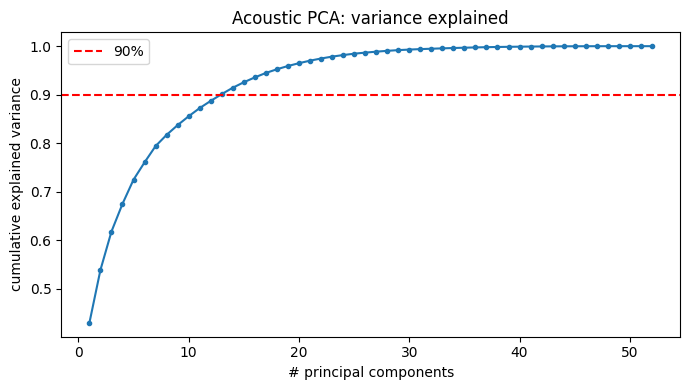

In [47]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = model_df[acoustic]
Xz = StandardScaler().fit_transform(X)          # for visualization only
pca = PCA().fit(Xz)
cum = np.cumsum(pca.explained_variance_ratio_)

for thr in [0.80, 0.90, 0.95]:
    k = int(np.argmax(cum >= thr) + 1)
    print(f"{int(thr*100)}% variance -> {k} components")

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum) + 1), cum, marker="o", ms=3)
plt.axhline(0.90, color="r", ls="--", label="90%")
plt.xlabel("# principal components"); plt.ylabel("cumulative explained variance")
plt.title("Acoustic PCA: variance explained"); plt.legend(); plt.tight_layout()
plt.savefig(DATA_DIR / "acoustic_pca_scree.png", dpi=150, bbox_inches="tight"); plt.show()


In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

y = model_df["phq9"]

def score(est, X, y, seeds=range(20)):
    r2, mae = [], []
    for s in seeds:
        kf = KFold(n_splits=10, shuffle=True, random_state=s)
        p = cross_val_predict(est, X, y, cv=kf, n_jobs=-1)
        r2.append(r2_score(y, p)); mae.append(mean_absolute_error(y, p))
    return np.mean(r2), np.std(r2), np.mean(mae)

def pca_pipe(n):
    return Pipeline([("scale", StandardScaler()),
                     ("pca",   PCA(n_components=n, random_state=SEED)),
                     ("rf",    RandomForestRegressor(random_state=SEED))])

print(f"{'model':16s}{'R2 (mean±sd)':>20}{'MAE':>10}")
r2m, r2s, maem = score(RandomForestRegressor(random_state=SEED), model_df[acoustic], y)
print(f"{'Full 88':16s}{f'{r2m:.3f}±{r2s:.3f}':>20}{maem:>10.3f}")
for n in [0.90, 15, 10, 5]:
    r2m, r2s, maem = score(pca_pipe(n), model_df[acoustic], y)
    label = f"PCA {int(n*100)}% var" if n < 1 else f"PCA {n} comps"
    print(f"{label:16s}{f'{r2m:.3f}±{r2s:.3f}':>20}{maem:>10.3f}")


model                   R2 (mean±sd)       MAE
Full 88                  0.205±0.028     6.414
PCA 90% var             -0.115±0.079     7.739
PCA 15 comps            -0.115±0.075     7.758
PCA 10 comps            -0.125±0.069     7.708
PCA 5 comps             -0.149±0.108     7.735


In [ ]:
# A-priori "collapse the functionals": keep mean + one variability measure per LLD,
# drop percentiles, percentile-ranges, and rising/falling-slope functionals.
DROP_MARKERS = ["percentile", "pctlrange", "RisingSlope", "FallingSlope"]
acoustic_collapsed = [c for c in acoustic if not any(m in c for m in DROP_MARKERS)]
dropped = [c for c in acoustic if c not in acoustic_collapsed]

print(f"Collapsed {len(acoustic)} -> {len(acoustic_collapsed)} features (dropped {len(dropped)})")
print("\nDropped functionals:")
for d in dropped: print("  ", d)

r2m, r2s, maem = score(RandomForestRegressor(random_state=SEED), model_df[acoustic_collapsed], y)
print(f"\nCollapsed {len(acoustic_collapsed)}: R2 {r2m:.3f}±{r2s:.3f}  MAE {maem:.3f}")
print("Full 88 baseline:   R2 0.205±0.028  MAE 6.414")


Collapsed 88 -> 72 features (dropped 16)

Dropped functionals:
   F0semitoneFrom27.5Hz_sma3nz_percentile20.0
   F0semitoneFrom27.5Hz_sma3nz_percentile50.0
   F0semitoneFrom27.5Hz_sma3nz_percentile80.0
   F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2
   F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope
   F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope
   F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope
   F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope
   loudness_sma3_percentile20.0
   loudness_sma3_percentile50.0
   loudness_sma3_percentile80.0
   loudness_sma3_pctlrange0-2
   loudness_sma3_meanRisingSlope
   loudness_sma3_stddevRisingSlope
   loudness_sma3_meanFallingSlope
   loudness_sma3_stddevFallingSlope

Collapsed 72: R2 0.228±0.031  MAE 6.282
Full 88 baseline:   R2 0.205±0.028  MAE 6.414


In [ ]:
r2m, r2s, maem= score(GradientBoostingRegressor(random_state=SEED), model_df[acoustic_collapsed], y)
print(f"\nCollapsed GBM {len(acoustic_collapsed)}: R2 {r2m:.3f}±{r2s:.3f}  MAE {maem:.3f}")


Collapsed GBM 72: R2 0.203±0.064  MAE 5.968
Full 88 baseline:   R2 0.205±0.028  MAE 6.414


In [ ]:

pd.Series(acoustic_collapsed, name="feature").to_csv(DATA_DIR / "acoustic_collapsed_features.csv", index=False)


In [ ]:
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.stats import pearsonr

# 72-feature acoustic set (functional collapse), single source of truth
acoustic = pd.read_csv(DATA_DIR / "acoustic_collapsed_features.csv")["feature"].tolist()
demo     = ["age", "gender", "education_years"]
psych    = ["ctq_sf", "LES", "SSRS", "gad7", "PSQI"]
clinical = demo + psych
y = model_df["phq9"]

feature_sets = {
    "Acoustic (72)":            acoustic,
    "Demographics + Acoustic":  demo + acoustic,
    "Clinical + Acoustic":      clinical + acoustic,
}
models = {"RF": RandomForestRegressor(random_state=SEED),
          "GBM": GradientBoostingRegressor(random_state=SEED)}

def repeated_cv(est, X, y, seeds=range(20)):
    rows = []
    for s in seeds:
        kf = KFold(n_splits=10, shuffle=True, random_state=s)
        p = cross_val_predict(est, X, y, cv=kf, n_jobs=-1)
        rows.append({"MAE": mean_absolute_error(y, p), "RMSE": np.sqrt(mean_squared_error(y, p)),
                     "R2": r2_score(y, p), "r": pearsonr(y, p)[0]})
    d = pd.DataFrame(rows)
    return {k: (d[k].mean(), d[k].std()) for k in ["MAE", "RMSE", "R2", "r"]}

print(f"{'feature set':26s}{'model':5s}{'R2':>15}{'MAE':>13}{'RMSE':>13}{'r':>13}")
for sname, cols in feature_sets.items():
    for mname, m in models.items():
        r = repeated_cv(m, model_df[cols], y)
        f = lambda k: f"{r[k][0]:.3f}±{r[k][1]:.3f}"
        print(f"{sname:26s}{mname:5s}{f('R2'):>15}{f('MAE'):>13}{f('RMSE'):>13}{f('r'):>13}")


feature set               model             R2          MAE         RMSE            r
Acoustic (72)             RF       0.228±0.032  6.282±0.150  7.380±0.152  0.478±0.032
Acoustic (72)             GBM      0.203±0.065  5.968±0.265  7.492±0.306  0.497±0.048
Demographics + Acoustic   RF       0.244±0.032  6.227±0.126  7.302±0.154  0.496±0.031
Demographics + Acoustic   GBM      0.169±0.084  6.129±0.301  7.650±0.376  0.470±0.055
Clinical + Acoustic       RF       0.762±0.027  2.828±0.157  4.095±0.226  0.875±0.015
Clinical + Acoustic       GBM      0.713±0.039  3.165±0.216  4.490±0.302  0.849±0.022


In [36]:
# Permutation test score to test statistical significance of the models (10-fold CV, 1000 permutations)

from sklearn.model_selection import permutation_test_score, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pandas as pd

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)
models = {"RF": RandomForestRegressor(random_state=SEED),
          "GBM": GradientBoostingRegressor(random_state=SEED)}
feature_sets = {
    "Demographics": DEMO, "Psych": PSYCH, "Clinical": CLINICAL,
    "Acoustic": ACOUSTIC, "Demo+Acoustic": DEMO_ACOUSTIC, "Clinical+Acoustic": CLINICAL_ACOUSTIC,
}

rows = []
for sname, cols in feature_sets.items():
    for mname, m in models.items():
        score, _, pval = permutation_test_score(
            m, model_df[cols], y, cv=kf,
            scoring="neg_mean_absolute_error",     # stable statistic; flip sign below
            n_permutations=1000, random_state=SEED, n_jobs=-1)
        rows.append({"feature_set": sname, "model": mname,
                     "cv_MAE": round(-score, 3), "p_value": round(pval, 4)})

perm = pd.DataFrame(rows)
print(perm.to_string(index=False))
perm.to_csv(DATA_DIR / "permutation_test_results.csv", index=False)


      feature_set model  cv_MAE  p_value
     Demographics    RF   5.911    0.004
     Demographics   GBM   6.144    0.003
            Psych    RF   2.546    0.001
            Psych   GBM   2.629    0.001
         Clinical    RF   2.645    0.001
         Clinical   GBM   2.718    0.001
         Acoustic    RF   6.160    0.002
         Acoustic   GBM   5.624    0.002
    Demo+Acoustic    RF   5.988    0.002
    Demo+Acoustic   GBM   6.039    0.007
Clinical+Acoustic    RF   2.708    0.001
Clinical+Acoustic   GBM   2.962    0.001


In [34]:
# Test whether n_jobs=-1 works in this kernel (dual-sklearn pickle check)
import time, numpy as np, sklearn
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold

print("sklearn:", sklearn.__version__, "|", sklearn.__file__)

Xt = np.random.RandomState(0).rand(52, 20)      # tiny dummy data, same shape ballpark
yt = np.random.RandomState(1).rand(52)
kf = KFold(n_splits=5, shuffle=True, random_state=0)

for name, est in [("RandomForest",     RandomForestRegressor(n_estimators=50, random_state=0)),
                  ("GradientBoosting", GradientBoostingRegressor(random_state=0))]:
    try:
        t = time.time()
        cross_val_score(est, Xt, yt, cv=kf, n_jobs=-1)      # forces parallel workers
        print(f"  {name:16s}: n_jobs=-1 OK  ({time.time()-t:.1f}s)")
    except Exception as e:
        print(f"  {name:16s}: n_jobs=-1 FAILS -> {type(e).__name__}: {str(e)[:120]}")


sklearn: 1.9.0 | C:\Users\zeine\AppData\Roaming\Python\Python311\site-packages\sklearn\__init__.py
  RandomForest    : n_jobs=-1 OK  (5.5s)
  GradientBoosting: n_jobs=-1 OK  (5.2s)


In [46]:
from importlib.metadata import version, PackageNotFoundError
for pkg in ["numpy", "pandas", "scikit-learn", "scipy",
            "matplotlib", "librosa", "soundfile", "shap"]:
    try:
        print(f"{pkg:15s}{version(pkg)}")
    except PackageNotFoundError:
        print(f"{pkg:15s}(not installed)")

import sys
print(f"{'Python':15s}{sys.version.split()[0]}")



numpy          2.2.6
pandas         2.2.2
scikit-learn   1.9.0
scipy          1.17.1
matplotlib     3.8.4
librosa        0.11.0
soundfile      0.14.0
shap           0.51.0
Python         3.11.3
